In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [3]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

# clean date
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# create new columns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# duration fix
df['duration'] = df['duration'].astype(str)
df['duration'] = df['duration'].str.extract(r'(\d+)')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

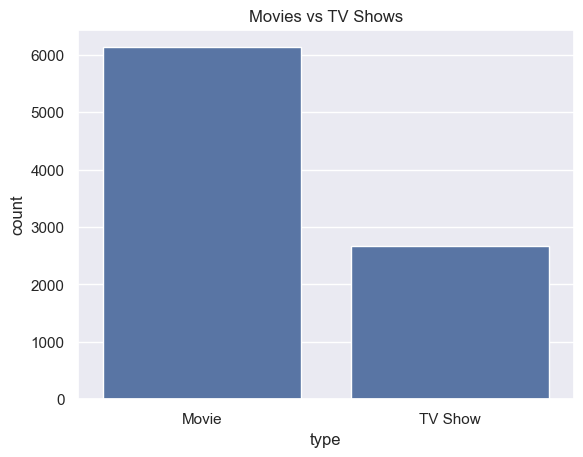

In [5]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

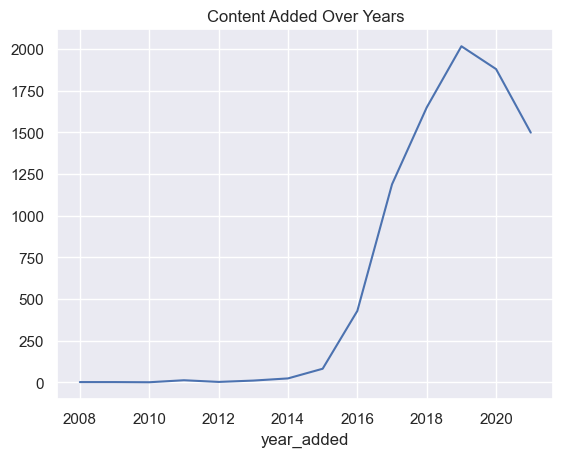

In [6]:
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.show()

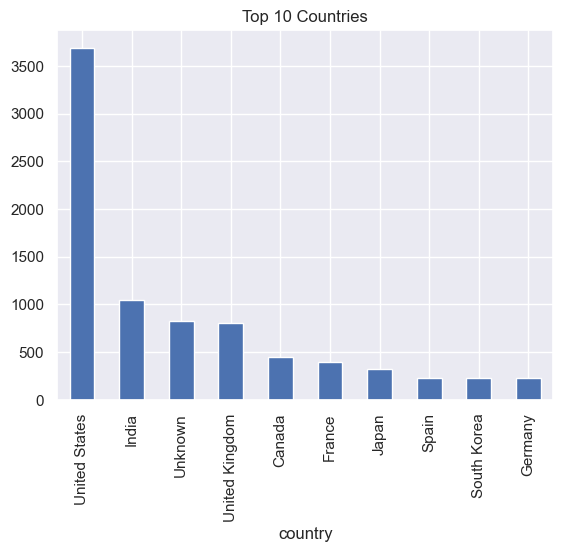

In [7]:
df_exploded = df.copy()
df_exploded['country'] = df_exploded['country'].str.split(',')
df_exploded = df_exploded.explode('country')
df_exploded['country'] = df_exploded['country'].str.strip()

top_countries = df_exploded['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

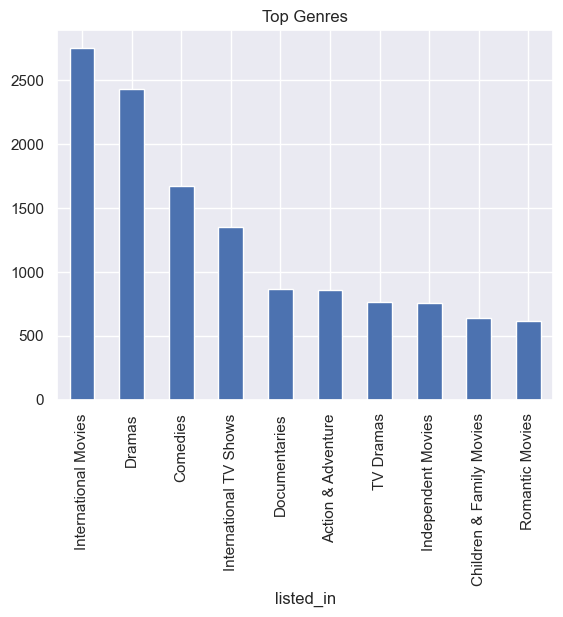

In [8]:
df_genre = df.copy()
df_genre['listed_in'] = df_genre['listed_in'].str.split(',')
df_genre = df_genre.explode('listed_in')
df_genre['listed_in'] = df_genre['listed_in'].str.strip()

top_genres = df_genre['listed_in'].value_counts().head(10)

top_genres.plot(kind='bar')
plt.title("Top Genres")
plt.show()

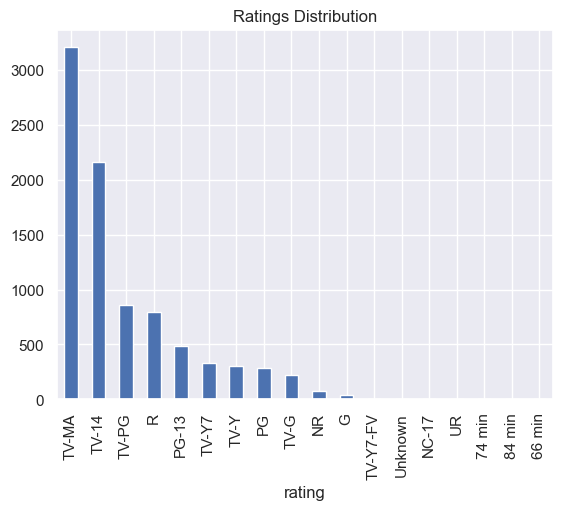

In [9]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Ratings Distribution")
plt.show()

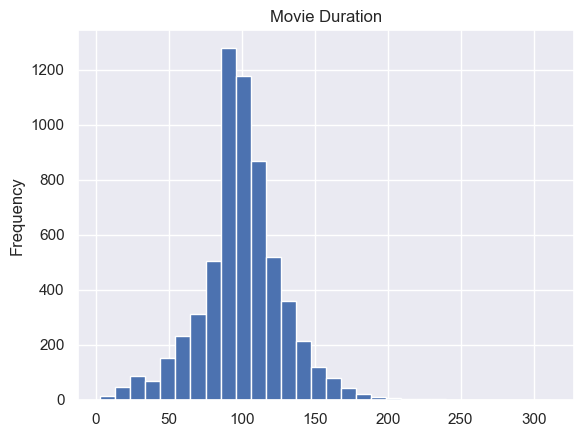

In [10]:
movies = df[df['type'] == 'Movie']
movies['duration'].plot(kind='hist', bins=30)

plt.title("Movie Duration")
plt.show()